<a href="https://colab.research.google.com/github/sandeepgangaram/neural-nets/blob/master/makemor/makemor_mlp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [324]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [325]:
words = open('./names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [326]:
len(words)

32033

In [327]:
from IPython.core.crashhandler import crash_handler_lite
#build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {char:i+1 for i,char in enumerate(chars)}
stoi['.'] = 0
itos = {i: char for char, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)
# itos

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [328]:
block_size = 3 #context length - characters to predict next character

# build the dataset
def build_dataset(words):
  X, Y = [],[]

  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context),'--->', itos[ix])
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])     #training set 80% - train parameters
Xdev, Ydev = build_dataset(words[n1:n2]) #dev/validation set 10% - train hyperparameters
Xte, Yte = build_dataset(words[n2:])     #test set 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [313]:
# putting it all together
n_embed = 10
n_hidden = 200
batch_size = 32
max_steps = 200000

g = torch.Generator().manual_seed(2147483647)

#input layer
C = torch.randn(vocab_size,n_embed, generator=g)

# hidden layer
W1 = torch.rand((n_embed*block_size, n_hidden), generator=g)*(5/3)/(n_embed*block_size)**0.5
b1 = torch.randn(n_hidden, generator=g)*0.1

#output layer
W2 = torch.randn((n_hidden,vocab_size), generator=g)*0.1
b2 = torch.rand(vocab_size, generator=g)*0

###
# batch norm parameters - learnable parameters
#  (used to keep guassian only on init and let network
# flow with the learning instaed of always constraining to a guassion)
###
bngain = torch.ones(1, n_hidden)
bnbias = torch.zeros(1, n_hidden)

#these are used at inference allowing to forward individual examples
bnmean_running = torch.zeros(1, n_hidden)
bnstd_running = torch.ones(1, n_hidden)


parameters = [C,W1, W2, b1, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

12297


tensor(0.0064) tensor(1.0166) tensor(1.0334)
tensor(0.0101) tensor(1.0105) tensor(1.0211)
tensor(-0.0169) tensor(3.2273) tensor(10.4158)


(array([7.28366789e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.18510037e-04, 2.91346716e-04, 1.45673358e-04,
        2.91346716e-04, 9.46876826e-04, 8.74040147e-04, 1.82091697e-03,
        3.05914051e-03, 4.95289416e-03, 7.06515785e-03, 1.03428084e-02,
        1.61697427e-02, 2.36719206e-02, 3.15382820e-02, 4.52315776e-02,
        6.05272802e-02, 8.03388568e-02, 9.84023532e-02, 1.09910548e-01,
        1.28556738e-01, 1.23093987e-01, 1.31688715e-01, 1.21637254e-01,
        1.09692038e-01, 8.92249316e-02, 7.38563924e-02, 5.43361625e-02,
        4.10070502e-02, 2.77507747e-02, 2.05399434e-02, 1.45673358e-02,
        8.66756479e-03, 5.89977099e-03, 3.56899727e-03, 2.11226369e-03,
        1.74808029e-03, 1.45673358e-03, 5.82693431e-04, 3.64183394e-04,
        2.18510037e-04, 2.91346716e-04]),
 array([-20.48793602, -19.8014687 , -19.11500137, -18.42853405,
        -17.74206673, -17.0555

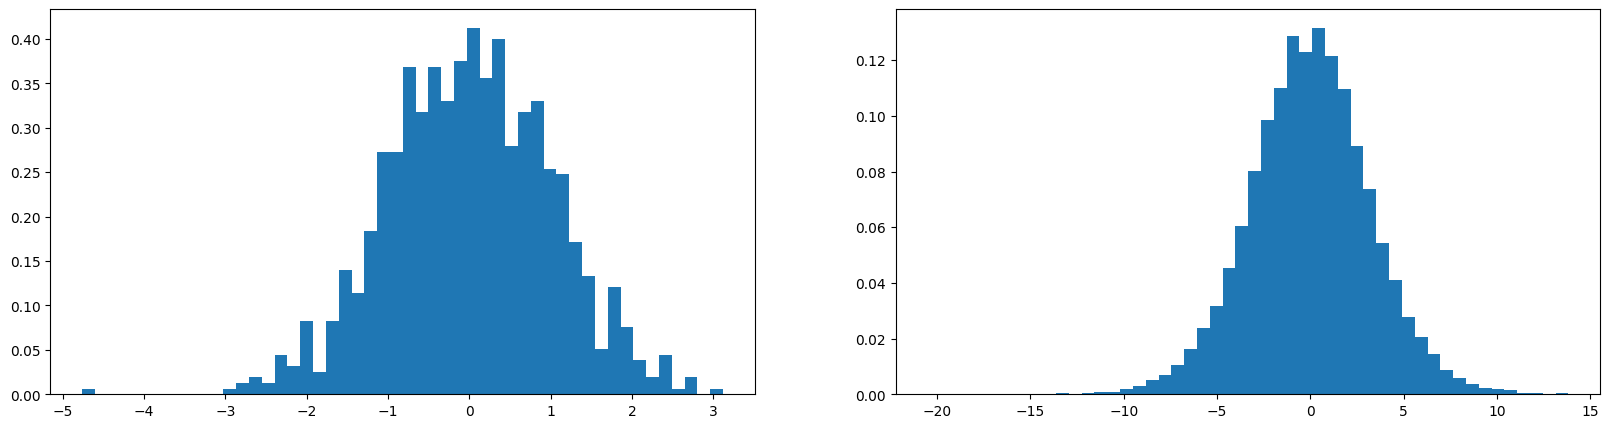

In [314]:
x = torch.randn(100,10)
w = torch.randn(10,200)
y = x@w
print(x.mean(), x.std(), x.var())
print(w.mean(), w.std(), w.var())
print(y.mean(), y.std(), y.var())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50, density=True)

In [ ]:
# hpreact.mean(0,keepdim=True).shape
# hpreact.std(0,keepdim=True).shape

In [ ]:

lossi = []

for i in range(max_steps):
  #mini-batch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  #forward-pass
  emb = C[Xb]
  embcat = emb.view(emb.shape[0],-1)
  hpreact = embcat@W1 + #b1 #hidden-layer preactiation (bias not needed in batch norm.)

  #batch normalization step
  bnmeani = hpreact.mean(0,keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain*((hpreact - bnmeani)/bnstdi) + bnbias

  with torch.no_grad():
    bnmean_running = 0.999*bnmean_running + 0.001*bnmeani
    bnstd_running = 0.999*bnstd_running + 0.001*bnstdi

  h = torch.tanh(hpreact)
  logits = h@W2 + b2
  loss = F.cross_entropy(logits,Yb)

  #backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #learning reate decay - once loss plateus, reduce the learning rate /10
  lr = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data -= lr*p.grad

  # print once in a while
  if i%10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  # break

In [ ]:
# plt.hist(h.view(-1).tolist(),50)

In [ ]:
# plt.hist(hpreact.view(-1).tolist(),50)

In [ ]:
# plt.figure(figsize=(20,10))
# plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [ ]:
# logits[0]

In [ ]:
# logits = torch.tensor([1.0,2.0,1.0,1.0])
# probs = F.softmax(logits, dim=0)
# loss = -probs[2].log()
# logits,probs,loss

In [ ]:
# -torch.tensor(1/27.0).log()

In [ ]:
plt.plot(lossi)

In [ ]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0],-1)
  hpreact = embcat@W1 + b1
  #measure the mean/std. over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [ ]:
bnstd_running

In [ ]:
bnstd

In [ ]:
@torch.no_grad() #decorator to disable gradient tracking - not required here
def split_loss(split):
  x,y = {
      'train':(Xtr,Ytr),
      'val':(Xdev,Ydev),
      'test':(Xte,Yte)
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0],-1)
  hpreact = embcat@W1 + b1
  #batch normalization step
  hpreact = bngain*((hpreact - bnmean_running)/bnstd_running) + bnbias
  h = torch.tanh(hpreact)
  logits = h@W2 + b2
  loss = F.cross_entropy(logits,y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

In [ ]:

#before - random initialization
# train 2.12
# val 2.16

##1
# fix softmax being confidently wrong -

# by changing initial output weights and biases bringing them closer to 0
# w2 * 0.1
# b2*0

# train 2.044
# val 2.11

##2 fix tanh layer too saturated at init
# train 2.05
# val 2.10

## use semi-principled "Kaiming" initalization instead of hacky init
# train 2.0452935695648193
# val 2.107194423675537

## add a batch normalization layer
# train 2.067406415939331
# val 2.10783314704895


In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))


In [ ]:
#batch noramalization is used to control the statistics of the activations in the neural net
#typiclly plced after a multiplication layer (ex: linear or convolutional layer)
#has parameters gain and bias that are also trained using back-propogation
#has buffers - mean and std. deviation - updated on each step

In [336]:
# Deeper Network

class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) /fan_in**0.5
    self.bias = torch.randn(fan_out, generator=g) if bias else None

  def __call__(self, x):
    self.out = x@self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    #parmeters (trained with bckprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    #buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self,x):
    #calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    #update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
        self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self,x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embed = 10 #the dimensionality of the character embedding vectors
n_hidden = 100 #the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) #for reporducibility

C = torch.randn((vocab_size, n_embed), generator=g)

layers = [
    Linear(n_embed*block_size, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden,bias=False), BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden,bias=False), BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden,bias=False), BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
  #make the last layer less confident
  # layers[-1].gamma *= 0.1 #since last layer is batch norm

  layers[-1].weight *= 0.1
  #all other layers apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True


46997


In [335]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  xi = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[xi], Ytr[xi] #batch X,Y

  # forward pass
  emb = C[Xb] #embed the characters into vectors
  x = emb.view(emb.shape[0],-1) #concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) #loss function

  # backward pass
  # The retain_grad debugging lines are commented out as they are not needed for the fix.
  # for layer in layers:
    #  layer.out.retain_grad() #to debug
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i<100000 else 0.01
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 == 0:
    print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])
    # ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])


  if i >1000:
    break # to debug


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.91%
layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 2.75%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.72%
layer 11 (      Tanh): mean -0.01, std 0.65, saturated: 1.94%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.66%


Text(0.5, 1.0, 'activation distribution')

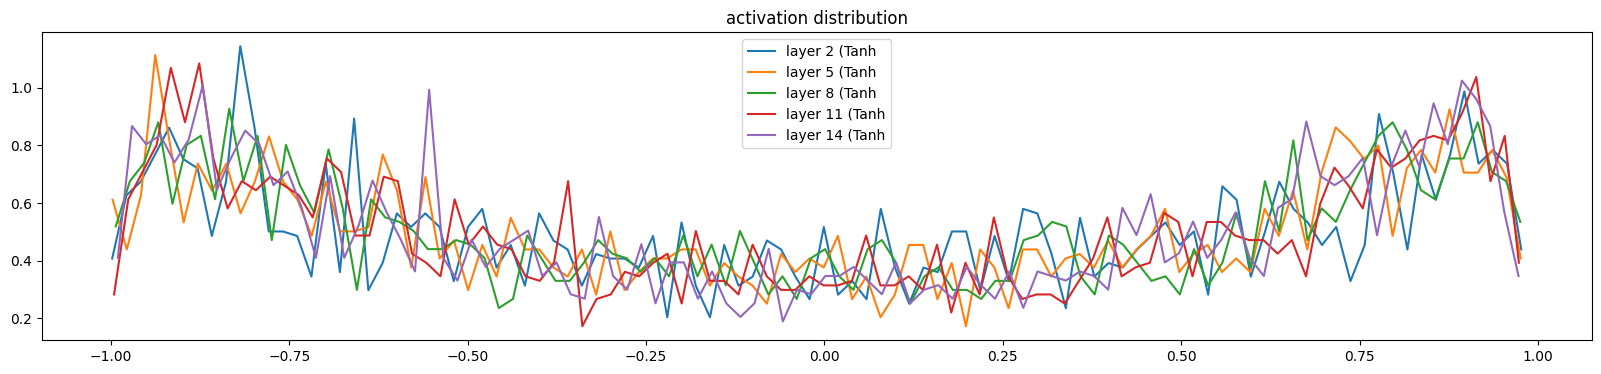

In [257]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 3.495707e-03
layer 5 (      Tanh): mean -0.000000, std 2.951500e-03
layer 8 (      Tanh): mean -0.000000, std 2.611986e-03
layer 11 (      Tanh): mean -0.000000, std 2.524609e-03
layer 14 (      Tanh): mean +0.000000, std 2.505544e-03


Text(0.5, 1.0, 'gradient distribution')

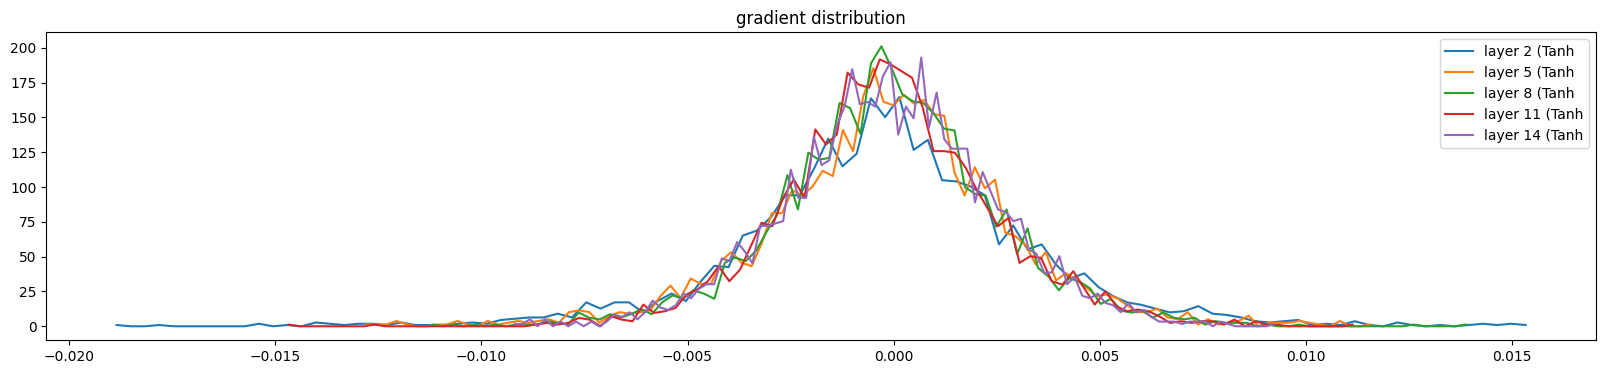

In [258]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 8.795537e-03 | grad:data ratio 8.786811e-03
weight  (30, 100) | mean +0.000113 | std 8.088296e-03 | grad:data ratio 2.587890e-02
weight (100, 100) | mean -0.000021 | std 7.160071e-03 | grad:data ratio 4.267828e-02
weight (100, 100) | mean +0.000089 | std 5.988698e-03 | grad:data ratio 3.604711e-02
weight (100, 100) | mean -0.000050 | std 5.043147e-03 | grad:data ratio 3.017230e-02
weight (100, 100) | mean +0.000019 | std 5.276988e-03 | grad:data ratio 3.148127e-02
weight  (100, 27) | mean +0.000167 | std 9.968236e-03 | grad:data ratio 5.957659e-02


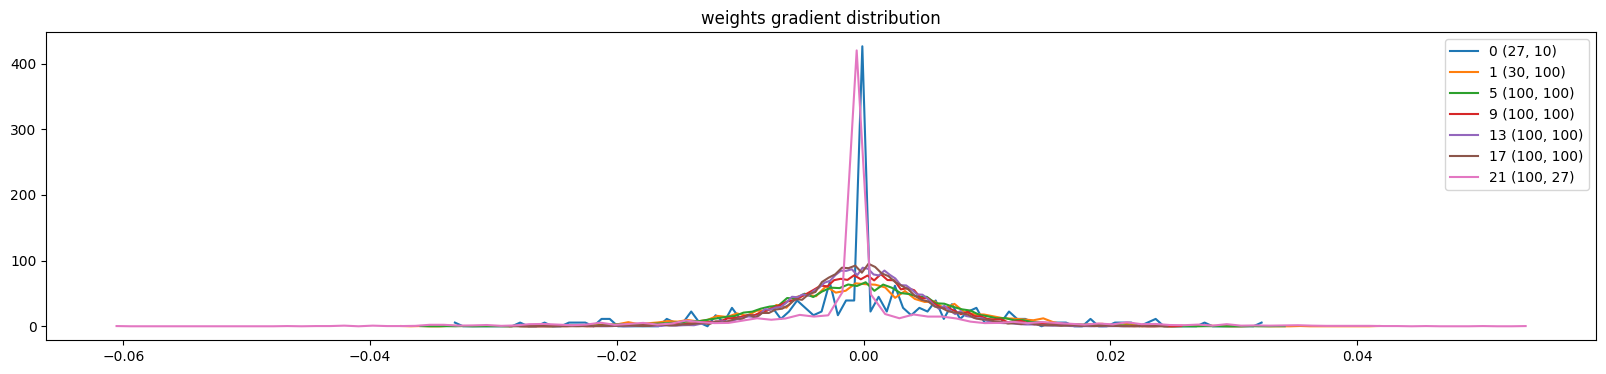

In [259]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

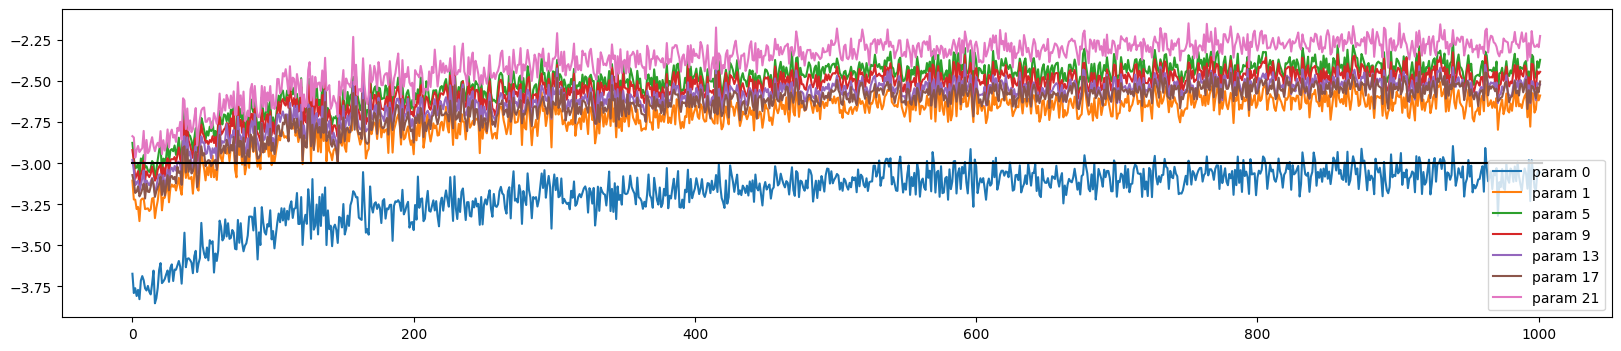

In [260]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);